# Problem Statement: 
 Create a robust traffic congestion prediction model, understand the key patterns of peak traffic hours, compare the performance of different junctions, and evaluate and refine the model to provide accurate forecasts. 	

# Task 1. Data Cleaning & Pre-processing

### **1. Load Raw Data:** 
Read the collected data into pandas DataFrames.

In [3]:
#import the warnings.
import warnings
warnings.filterwarnings("ignore")

In [5]:
import numpy as np
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [9]:
!pip install gdown

In [10]:
file_id = '1zwIlTiobpHEz8DxNtSjeChfN5Xte1mk3'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'traffic_dataset.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1zwIlTiobpHEz8DxNtSjeChfN5Xte1mk3
To: C:\Users\Sheetal Rawat\Mentornship\Traffic-Congestion-Prediction\traffic_dataset.csv
100%|█████████████████████████████████████████████████████████████████████████████| 1.55M/1.55M [00:00<00:00, 4.40MB/s]


'traffic_dataset.csv'

In [7]:
df_traffic = pd.read_csv('traffic_dataset.csv')

In [9]:
df_traffic.head()

,DateTime,Junction,Vehicles,ID
0,01/11/15 0:00,1,15,20151101001
1,01/11/15 1:00,1,13,20151101011
2,01/11/15 2:00,1,10,20151101021
3,01/11/15 3:00,1,7,20151101031
4,01/11/15 4:00,1,9,20151101041


### **2. Clean Data:**
- Handle missing values using methods like imputation or removal (df.fillna(), df.dropna()). 
- Remove duplicates (df.drop_duplicates()).
- Correct data types (df.astype()).

In [12]:
100 * (df_traffic.isnull().mean())

DateTime    0.0
Junction    0.0
Vehicles    0.0
ID          0.0
dtype: float64

In [14]:
df_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [16]:
df_traffic.head()

,DateTime,Junction,Vehicles,ID
0,01/11/15 0:00,1,15,20151101001
1,01/11/15 1:00,1,13,20151101011
2,01/11/15 2:00,1,10,20151101021
3,01/11/15 3:00,1,7,20151101031
4,01/11/15 4:00,1,9,20151101041


In [18]:
# Convert the 'DateTime' column to datetime
df_traffic['DateTime'] = pd.to_datetime(df_traffic['DateTime'])

In [19]:
df_traffic.head()

,DateTime,Junction,Vehicles,ID
0,2015-01-11 00:00:00,1,15,20151101001
1,2015-01-11 01:00:00,1,13,20151101011
2,2015-01-11 02:00:00,1,10,20151101021
3,2015-01-11 03:00:00,1,7,20151101031
4,2015-01-11 04:00:00,1,9,20151101041


In [20]:
df_traffic.dtypes

DateTime    datetime64[ns]
Junction             int64
Vehicles             int64
ID                   int64
dtype: object

### **3. Aggregate traffic data:**
- Compile traffic data into hourly intervals for each junction.
- Ensure data includes relevant details such as vehicle counts.

In [22]:
df_traffic.head()

,DateTime,Junction,Vehicles,ID
0,2015-01-11 00:00:00,1,15,20151101001
1,2015-01-11 01:00:00,1,13,20151101011
2,2015-01-11 02:00:00,1,10,20151101021
3,2015-01-11 03:00:00,1,7,20151101031
4,2015-01-11 04:00:00,1,9,20151101041


In [25]:
# Group by hour and junction to analyze traffic patterns
hourly_traffic = df_traffic.groupby([df_traffic['DateTime'].dt.hour, 'Junction'])['Vehicles'].sum().unstack()

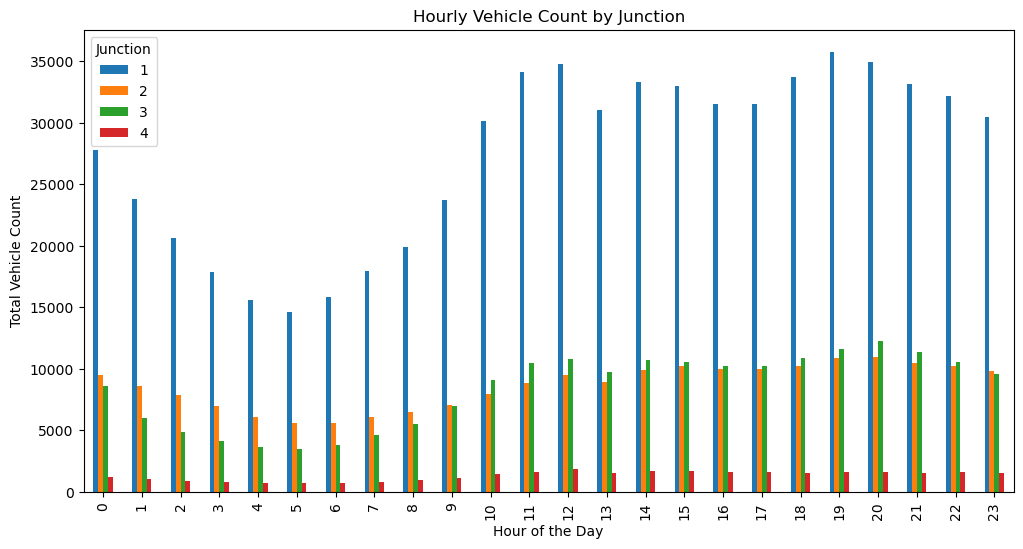

In [29]:
# Plotting the hourly traffic
hourly_traffic.plot(kind='bar', figsize=(12, 6))
plt.title('Hourly Vehicle Count by Junction')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Vehicle Count')
plt.legend(title='Junction')
plt.show()

In [35]:
# Correlation analysis
correlation = df_traffic.corr()
print(correlation['Vehicles'])

DateTime    0.231934
Junction   -0.613787
Vehicles    1.000000
ID          0.227974
Name: Vehicles, dtype: float64


In [ ]:

# Plotting the hourly traffic
hourly_traffic.plot(kind='bar', figsize=(12, 6))
plt.title('Hourly Vehicle Count by Junction')
plt.xlabel('Hour of the Day')
plt.ylabel('Total Vehicle Count')
plt.legend(title='Junction')
plt.show()

# Correlation analysis
correlation = data.corr()
print(correlation['vehicle_count']

In [66]:
# Group by Date, Junction, and Hour to aggregate traffic data
df_traffic = df_traffic.groupby(['DateTime', 'Junction'])['Vehicles'].sum().reset_index()

In [68]:
df_traffic.head()

,DateTime,Junction,Vehicles
0,2015-01-11 00:00:00,1,15
1,2015-01-11 00:00:00,2,6
2,2015-01-11 00:00:00,3,9
3,2015-01-11 01:00:00,1,13
4,2015-01-11 01:00:00,2,6


### **4. Preprocess the data:**

Normalize or standardize the data to facilitate comparison across different time periods and junctions.

In [177]:
df_traffic['Vehicles'].unique()

array([ 15,   6,   9,  13,   7,  10,   5,   1,   2,   4,   3,   8,  11,
        12,  17,  16,  20,  19,  21,  18,  14,  30,  29,  28,  31,  26,
        25,  27,  24,  22,  32,  35,  34,  39,  38,  33,  23,  36,  40,
        48,  43,  41,  37,  42,  44,  47,  50,  46,  45,  52,  53,  64,
        61,  58,  51,  49,  55,  72,  71,  62,  66,  65,  54,  59,  57,
        56,  68,  78,  77,  63,  69,  91,  86,  80,  76,  81,  79,  73,
        70,  67,  60,  75, 120,  82,  74,  85,  83, 100,  88,  84,  93,
        89,  98, 114, 134, 105, 111, 132, 109,  97,  90, 103,  87,  94,
        92, 106,  96, 121, 110, 102, 107, 117, 112,  95, 143, 135, 141,
       156,  99, 124, 113, 115, 180, 173, 101, 108, 104, 136, 129, 118,
       116, 123, 133, 128, 127, 140, 126, 119, 162, 122, 125], dtype=int64)

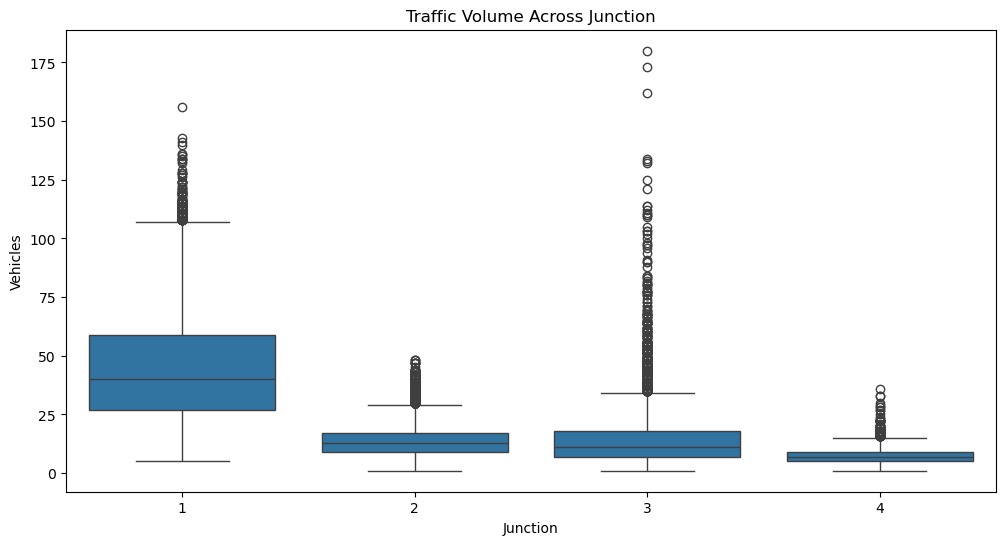

In [178]:
# Plot the normalized data for comparison
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_traffic, x='Junction', y='Vehicles')
plt.title('Traffic Volume Across Junction')
plt.show()

### as we can see there are outliers in our dataset so its better to remove it by using IQR method

In [180]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df_traffic['Vehicles'].quantile(0.25)
Q3 = df_traffic['Vehicles'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_traffic[(df_traffic['Vehicles'] < lower_bound) | (df_traffic['Vehicles'] > upper_bound)]

# Option 1: Remove outliers
df_traffic = df_traffic[(df_traffic['Vehicles'] >= lower_bound) & (df_traffic['Vehicles'] <= upper_bound)]

In [181]:
df_traffic.shape

(44503, 3)

In [182]:
print(Q1, Q3)

9.0 29.0


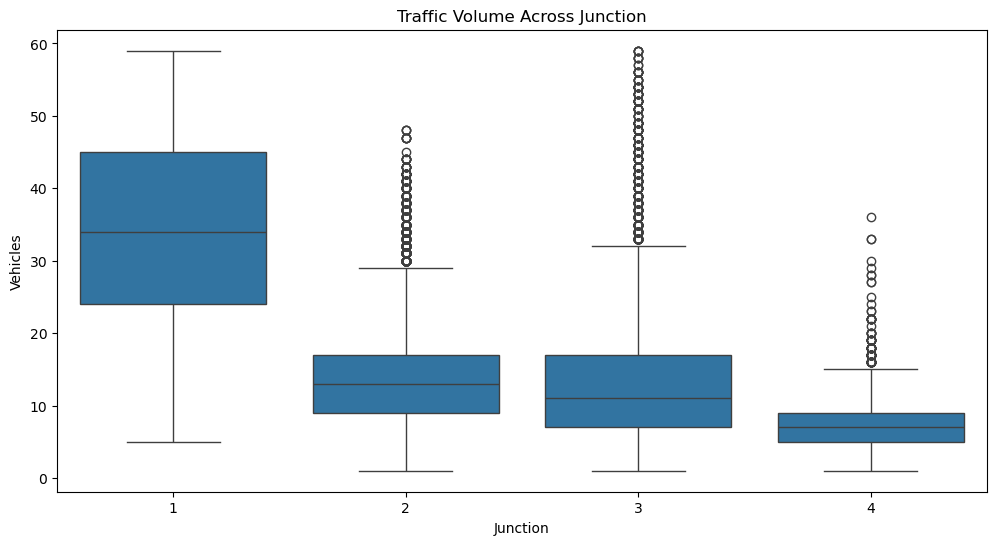

In [183]:
# Plot the normalized data for comparison
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_traffic, x='Junction', y='Vehicles')
plt.title('Traffic Volume Across Junction')
plt.show()

In [184]:
df_traffic.head()

,DateTime,Junction,Vehicles
0,2015-01-11 00:00:00,1,15
1,2015-01-11 00:00:00,2,6
2,2015-01-11 00:00:00,3,9
3,2015-01-11 01:00:00,1,13
4,2015-01-11 01:00:00,2,6


In [185]:
# Min-Max Scaling for Vehicles column
df_traffic['Vehicles'] = (df_traffic['Vehicles'] - df_traffic['Vehicles'].min()) / (df_traffic['Vehicles'].max() - df_traffic['Vehicles'].min())

In [186]:
df_traffic

,DateTime,Junction,Vehicles
0,2015-01-11 00:00:00,1,0.241379
1,2015-01-11 00:00:00,2,0.086207
2,2015-01-11 00:00:00,3,0.137931
3,2015-01-11 01:00:00,1,0.206897
4,2015-01-11 01:00:00,2,0.086207
...,...,...,...
48114,2017-12-06 22:00:00,3,0.224138
48115,2017-12-06 22:00:00,4,0.172414
48117,2017-12-06 23:00:00,2,0.586207
48118,2017-12-06 23:00:00,3,0.275862


# Task 2. Feature Engineering and Selection
1. Create new features from raw data:
Generate time-based features such as hour of the day, day of the week, and month.
Develop lag features by including traffic data from previous hours or days to capture temporal dependencies.
Create binary indicators for weekends and special events to account for their impact on traffic.

2. Evaluate feature importance:
Use statistical methods and machine learning techniques (e.g., correlation analysis, feature importance from tree-based models) to assess the relevance of each feature.
Select the most influential features for model training to improve efficiency and performance.

In [188]:
df_traffic.head()

,DateTime,Junction,Vehicles
0,2015-01-11 00:00:00,1,0.241379
1,2015-01-11 00:00:00,2,0.086207
2,2015-01-11 00:00:00,3,0.137931
3,2015-01-11 01:00:00,1,0.206897
4,2015-01-11 01:00:00,2,0.086207


In [40]:
# Create time-based features
df_traffic['Hour'] = df_traffic['DateTime'].dt.hour
df_traffic['DayOfWeek'] = df_traffic['DateTime'].dt.dayofweek  # Monday=0, Sunday=6
df_traffic['Month'] = df_traffic['DateTime'].dt.month

# Create binary indicator for weekends (Saturday=5, Sunday=6)
df_traffic['Weekend'] = df_traffic['DayOfWeek'].isin([5, 6]).astype(int)

# Lag Features (previous hour and previous day)
df_traffic['Vehicles_Lag1'] = df_traffic.groupby('Junction')['Vehicles'].shift(1)  # lag by 1 hour
df_traffic['Vehicles_Lag24'] = df_traffic.groupby('Junction')['Vehicles'].shift(24)  # lag by 1 day (assuming hourly data)

In [190]:
df_traffic.head()

,Junction,Vehicles,hour_of_day,day_of_week,month,lag_1_hour,lag_24_hours,is_weekend
DateTime,,,,,,,,
2015-01-11 00:00:00,1,0.241379,0,6,1,NaN,NaN,1
2015-01-11 00:00:00,2,0.086207,0,6,1,0.241379,NaN,1
2015-01-11 00:00:00,3,0.137931,0,6,1,0.086207,NaN,1
2015-01-11 01:00:00,1,0.206897,1,6,1,0.137931,NaN,1
2015-01-11 01:00:00,2,0.086207,1,6,1,0.206897,NaN,1


In [198]:
100 * (df_traffic.isnull().mean())

Junction        0.000000
Vehicles        0.000000
hour_of_day     0.000000
day_of_week     0.000000
month           0.000000
lag_1_hour      0.002247
lag_24_hours    0.053929
is_weekend      0.000000
dtype: float64

In [213]:
df_traffic.dropna(subset=['lag_1_hour'], inplace=True)
df_traffic.dropna(subset=['lag_24_hours'], inplace=True)

In [215]:
df_traffic.head()

,Junction,Vehicles,hour_of_day,day_of_week,month,lag_1_hour,lag_24_hours,is_weekend
DateTime,,,,,,,,
2015-01-11 08:00:00,1,0.172414,8,6,1,0.051724,0.241379,1
2015-01-11 08:00:00,2,0.034483,8,6,1,0.172414,0.086207,1
2015-01-11 08:00:00,3,0.034483,8,6,1,0.034483,0.137931,1
2015-01-11 09:00:00,1,0.189655,9,6,1,0.034483,0.206897,1
2015-01-11 09:00:00,2,0.034483,9,6,1,0.189655,0.086207,1


# Correlation Analysis

In [218]:
# Calculate the correlation matrix
correlation_matrix = df_traffic.corr()

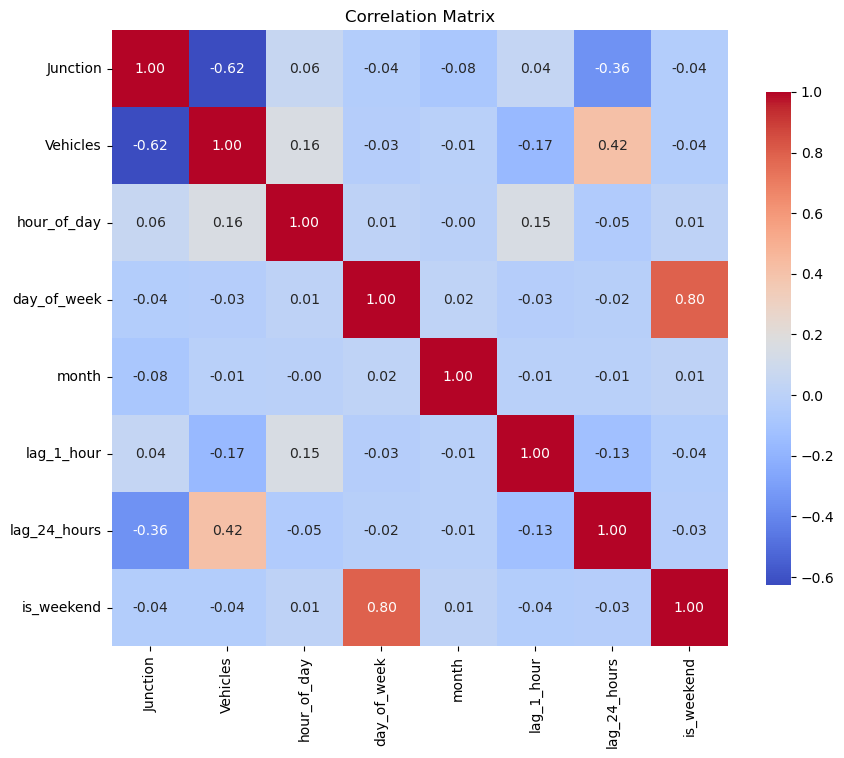

In [220]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 8))
# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
# Set the title
plt.title('Correlation Matrix')
# Show the plot
plt.show()

 ## as it has been clearly shown that lag_2_hour column is negatively correlated

In [ ]:
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['Month'] = df['DateTime'].dt.month

df['Vehicles_Lag1'] = df['Vehicles'].shift(1)
df_traffic['Vehicles_Lag24'] = df_traffic['Vehicles'].shift(24)

df_traffic['IsHoliday'] = df_traffic['DateTime'].apply(lambda x: 1 if x in holidays else 0) 

In [60]:
# Check the date range
start_date = hourly_traffic['DateTime'].min()
end_date = hourly_traffic['DateTime'].max()

print(f"Date range: {start_date} to {end_date}")

Date range: 2015-01-11 00:00:00 to 2017-12-06 23:00:00


# importing weather dataset

In [139]:
df_weather = pd.read_csv("weather.csv", skiprows=14)

In [141]:
df_weather.head()

,YEAR,MO,DY,HR,T2M,T2MDEW,QV2M,RH2M,PRECTOTCORR,WS10M
0,2015,1,11,0,7.33,-3.56,2.92,45.45,0.0,3.61
1,2015,1,11,1,6.59,-3.77,2.88,47.15,0.0,3.57
2,2015,1,11,2,5.91,-3.90,2.85,48.88,0.0,3.46
3,2015,1,11,3,5.32,-4.02,2.82,50.36,0.0,3.38
4,2015,1,11,4,4.84,-4.14,2.80,51.71,0.0,3.34


In [143]:
df_weather.shape

(25464, 10)

In [145]:
df_weather.isnull().sum()

YEAR           0
MO             0
DY             0
HR             0
T2M            0
T2MDEW         0
QV2M           0
RH2M           0
PRECTOTCORR    0
WS10M          0
dtype: int64

# importing public holidays

In [42]:
pip install holidays

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.2 MB 495.5 kB/s eta 0:00:03
   ---- ----------------------------------- 0.1/1.2 MB 1.0 MB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.2 MB 1.2 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.2 MB 2.2 MB/s eta 0:00:01
   ------------------------ --------------- 0.7/1.2 MB 2.9 MB/s eta 0:00:01
   -------------------------------- ------- 1.0/1.2 MB 3.5 MB/s eta 0:00:01
   ----------------------------------- ---- 1.1/1.2 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------  1.2/1.2 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 3.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [89]:
import pandas as pd
import holidays
from datetime import datetime

# Create a holiday object for India
india_holidays = holidays.India(years=range(2015, 2018))

# Define the date range
start_date = datetime.strptime('2015-01-11', '%Y-%m-%d')
end_date = datetime.strptime('2017-12-06', '%Y-%m-%d')

# Generate a date range
date_range = pd.date_range(start=start_date, end=end_date)

# Create a DataFrame with all dates
df_holidays = pd.DataFrame(date_range, columns=['date'])

# Add a column to indicate the holiday name or NaN
df_holidays['holiday'] = df_holidays['date'].apply(lambda x: india_holidays.get(x, None))

In [95]:
df_holidays.shape

(1061, 2)

In [97]:
df_holidays.head()

,date,holiday
0,2015-01-11,None
1,2015-01-12,None
2,2015-01-13,None
3,2015-01-14,Makar Sankranti / Pongal
4,2015-01-15,None


# Develop a data integration pipeline to merge traffic, weather, and event data into a unified dataset.

In [127]:
df_weather.columns.tolist()

['YEAR',
 'MO',
 'DY',
 'HR',
 'T2M',
 'T2MDEW',
 'QV2M',
 'RH2M',
 'PRECTOTCORR',
 'WS10M']

In [135]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25464 entries, 0 to 25463
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         25464 non-null  int64  
 1   MO           25464 non-null  int64  
 2   DY           25464 non-null  int64  
 3   HR           25464 non-null  int64  
 4   T2M          25464 non-null  float64
 5   T2MDEW       25464 non-null  float64
 6   QV2M         25464 non-null  float64
 7   RH2M         25464 non-null  float64
 8   PRECTOTCORR  25464 non-null  float64
 9   WS10M        25464 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 1.9 MB


In [155]:
# Step 1: Transform Weather Data
# Create a 'datetime' column in the weather DataFrame
df_weather['datetime'] = pd.to_datetime(
    df_weather['YEAR'].astype(str) + '-' +
    df_weather['MO'].apply(lambda x: f'{x:02}') + '-' +  # Zero-pad month
    df_weather['DY'].apply(lambda x: f'{x:02}') + ' ' +  # Zero-pad day
    df_weather['HR'].astype(str) + ':00:00'
)

In [157]:
# Drop the original YEAR, MO, DY, HR columns if no longer needed
df_weather.drop(columns=['YEAR', 'MO', 'DY', 'HR'], inplace=True)

In [159]:
# Step 2: Merge Traffic and Weather Data
# Ensure the traffic DataFrame is sorted by DateTime
df_traffic.sort_values('DateTime', inplace=True)

# Merge traffic and weather data on DateTime
merged_data = pd.merge_asof(df_traffic, df_weather, left_on='DateTime', right_on='datetime', direction='nearest')

In [161]:
# Step 3: Merge with Holidays Data
# Convert the 'date' column in holidays DataFrame to datetime
df_holidays['date'] = pd.to_datetime(df_holidays['date'])

# Merge with holidays data
merged_data = pd.merge_asof(merged_data.sort_values('DateTime'), 
                             df_holidays.sort_values('date'), 
                             left_on='DateTime', 
                             right_on='date', 
                             direction='nearest', 
                             suffixes=('', '_holiday'))

In [163]:
# Step 4: Handle Missing Values
# Check for missing values
print(merged_data.isnull().sum())

DateTime           0
Junction           0
Vehicles           0
T2M                0
T2MDEW             0
QV2M               0
RH2M               0
PRECTOTCORR        0
WS10M              0
datetime           0
date               0
holiday        45577
dtype: int64


In [165]:
# Step 5: Save the Unified Dataset
merged_data.to_csv('unified_dataset.csv', index=False)

# Display the first few rows of the merged dataset
print(merged_data.head())

             DateTime  Junction  Vehicles   T2M  T2MDEW  QV2M   RH2M  \
0 2015-01-11 00:00:00         1        15  7.33   -3.56  2.92  45.45   
1 2015-01-11 00:00:00         2         6  7.33   -3.56  2.92  45.45   
2 2015-01-11 00:00:00         3         9  7.33   -3.56  2.92  45.45   
3 2015-01-11 01:00:00         1        13  6.59   -3.77  2.88  47.15   
4 2015-01-11 01:00:00         2         6  6.59   -3.77  2.88  47.15   

   PRECTOTCORR  WS10M            datetime       date holiday  
0          0.0   3.61 2015-01-11 00:00:00 2015-01-11    None  
1          0.0   3.61 2015-01-11 00:00:00 2015-01-11    None  
2          0.0   3.61 2015-01-11 00:00:00 2015-01-11    None  
3          0.0   3.57 2015-01-11 01:00:00 2015-01-11    None  
4          0.0   3.57 2015-01-11 01:00:00 2015-01-11    None  


In [169]:
final_df = pd.read_csv('unified_dataset.csv')

In [171]:
# Drop the original columns if no longer needed
final_df.drop(columns=['datetime', 'date'], inplace=True)

In [173]:
final_df.head()

,DateTime,Junction,Vehicles,T2M,T2MDEW,QV2M,RH2M,PRECTOTCORR,WS10M,holiday
0,2015-01-11 00:00:00,1,15,7.33,-3.56,2.92,45.45,0.0,3.61,NaN
1,2015-01-11 00:00:00,2,6,7.33,-3.56,2.92,45.45,0.0,3.61,NaN
2,2015-01-11 00:00:00,3,9,7.33,-3.56,2.92,45.45,0.0,3.61,NaN
3,2015-01-11 01:00:00,1,13,6.59,-3.77,2.88,47.15,0.0,3.57,NaN
4,2015-01-11 01:00:00,2,6,6.59,-3.77,2.88,47.15,0.0,3.57,NaN


In [175]:
# Define a dictionary for renaming columns
new_column_names = {
    'Vehicles': 'vehicle_count',
    'T2M': 'temperature',
    'T2MDEW': 'dew_point',
    'QV2M': 'specific humidity',
    'RH2M': 'relative_humidity',
    'PRECTOTCORR': 'precipitation',
    'WS10M': 'wind_speed'
}
# Rename the columns
final_df.rename(columns=new_column_names, inplace=True)

In [177]:
final_df.head()

,DateTime,Junction,vehicle_count,temperature,dew_point,specific humidity,relative_humidity,precipitation,wind_speed,holiday
0,2015-01-11 00:00:00,1,15,7.33,-3.56,2.92,45.45,0.0,3.61,NaN
1,2015-01-11 00:00:00,2,6,7.33,-3.56,2.92,45.45,0.0,3.61,NaN
2,2015-01-11 00:00:00,3,9,7.33,-3.56,2.92,45.45,0.0,3.61,NaN
3,2015-01-11 01:00:00,1,13,6.59,-3.77,2.88,47.15,0.0,3.57,NaN
4,2015-01-11 01:00:00,2,6,6.59,-3.77,2.88,47.15,0.0,3.57,NaN


In [185]:
final_df['holiday'].unique()

array([nan, 'Diwali', 'Mawlid (estimated)', 'Christmas Day',
       'Makar Sankranti / Pongal', 'Republic Day', 'Palm Sunday', 'Holi',
       'Good Friday', 'Easter Sunday', 'Labour Day', 'Feast of Pentecost',
       'Eid ul-Fitr (estimated)', 'Independence Day',
       'Eid al-Adha (estimated)', 'Gandhi Jayanti',
       'Day of Ashura (estimated)'], dtype=object)